In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

from flask import Flask, render_template, request

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("=========================================")
print("A Comprehensive Measure of Well-Being")
print("All required libraries imported successfully!")
print("=========================================")

A Comprehensive Measure of Well-Being
All required libraries imported successfully!


In [2]:
import pandas as pd

df = pd.read_csv("../DataSet/Continent_HDI.csv")

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

   Unnamed: 0  Id     Human development groups    HDI  Life_ expectancy  Mean years of schooling  Gross national income (GNI) per capita  Average annual HDI growth 1990-2000  Average annual HDI growth 2000-2010  Average annual HDI growth 2010-2015  Average annual HDI growth 1990-2015  Gender Development Index value  Human Development Index (HDI) Female  Human Development Index (HDI) Male  Life expectancy at birth Female  Life expectancy at birth Male  Mean years of schooling Female  Mean years of schooling Male  Estimated gross national income per capita Female  Estimated gross national income per capita Male  Share of seats in parliament (% held by women)  Population with at least some secondary education % (2005-2015) Female  Population with at least some secondary education % (2005-2015) Male  Labour force participation rate (% ages 15 and older) Female   Total Population (millions) 2015  Total Population (millions) 2030  Population Average annual growth 2000/2005 (%)   \
0         

In [3]:
import pandas as pd

WellBeing = pd.read_csv("../DataSet/Continent_HDI.csv")

WellBeing.head()


,Unnamed: 0,Id,Human development groups,HDI,Life_ expectancy,Mean years of schooling,Gross national income (GNI) per capita,Average annual HDI growth 1990-2000,Average annual HDI growth 2000-2010,Average annual HDI growth 2010-2015,Average annual HDI growth 1990-2015,Gender Development Index value,Human Development Index (HDI) Female,Human Development Index (HDI) Male,Life expectancy at birth Female,Life expectancy at birth Male,Mean years of schooling Female,Mean years of schooling Male,Estimated gross national income per capita Female,Estimated gross national income per capita Male,Share of seats in parliament (% held by women),Population with at least some secondary education % (2005-2015) Female,Population with at least some secondary education % (2005-2015) Male,Labour force participation rate (% ages 15 and older) Female,Total Population (millions) 2015,Total Population (millions) 2030,Population Average annual growth 2000/2005 (%),Population Average annual growth 2010/2015 (%),Population Urban 2015 %,Population Under age 5 (millions) 2015,Population Ages 15–64 (millions) 2015,Population Ages 65 and older (millions) 2015,Population Median age (years) 2015,Dependency Ration Young age (0–14) /(per 100 people ages 15–64),Dependency Ratio Old age (65 and older) /(per 100 people ages 15–64),Total fertility rate (birth per woman) 2000/2005,Total fertility rate (birth per woman) 2000/2007,Infants exclusively breastfed (% ages 0–5 months) 2010-2015,Infants lacking immunization DTP (% of one-year-olds),Infants lacking immunization Measles (% of one-year-olds),Child malnutrition Stunting (moderate or severe) 2010-2015,"Mortality rates Infant (per 1,000 live births) 2015","Mortality rates Under-five (per 1,000 live births) 2015","Mortality rates Female Adult (per 1,000 live births) 2014","Mortality rates Male Adult (per 1,000 live births) 2014","Deaths due to Malria (per 100,000 people)","Deaths due to Tuberculosis (per 100,000 people)","HIV prevalence, adult (% ages 15–49)",Life expectancy at age 59 (years) 2010/2015,"Physicians (per 10,000 people) 2001-2014",Public health expenditure (% of GDP) 2014,Employment to population ratio (% ages 15 and older),Labour force participation rate (% ages 15 and older),Employment in agriculture (% of total employment) 2010-2014,Employment in services (% of total employment) 2010- 2014,Total Unemployment (% of labour force) 2015,Unemployment Youth (% ages 15-24) 2010-2014,Unemployment Youth not in school or employment (% ages 15-24) 2010-2014,Vulnerable employment (% of total employment) 2005-2014,Child labour (% ages 5-14) 2009-2015,Working poor at PPP$3.10 a day (%) 2004-2013,Mandatory paid maternity leave (days),Old-age pension recipients (% of statutory pension age population) 2004-2013,Internet users,Internet users (% 2010 -2015),Inequality-adjusted HDI (IHDI),Inequality-adjusted HDI (IHDI) Over loss(%),Coefficient of human inequality,Inequality in life expectancy (%) 2010-2015,Inequality-adjusted life expectancy index,Inequality in education(%),Inequality-adjusted education index,Inequality in income (%),Inequality-adjusted income index
0,0,1,Very high human development,0.892,79.4,12.2,39605,0.55,0.48,0.35,0.48,0.980,0.881,0.898,82.4,76.6,12.1,12.2,29234,50284,25.8,88.4,89.3,52.6,1350.099976,1414.300049,0.6,0.5,80.4,77.1,870.799988,225.3,40.2,25.7,25.2,1.6,1.7,NaN,2,6,NaN,5.4,6.3,NaN,NaN,NaN,2.0,0.4,23.4,30.9,7.5,56.4,60.4,3.8,72.7,6.8,16.3,13.4,NaN,NaN,NaN,114.0,90.4,79.4,11.3,0.793,11.1,10.9,5.4,0.865,7.2,0.797,19.9,0.723
1,1,2,High human development,0.746,75.5,8.1,13844,1.04,1.19,0.83,1.06,0.958,0.728,0.760,77.7,73.4,7.8,8.3,10214,17384,21.6,66.9,74.0,56.5,2379.399902,2524.399902,0.8,0.8,62.7,165.3,1683.599976,210.4,34.4,28.3,12.4,1.8,1.8,29.3,3,3,10.4,11.6,13.4,79.0,129.0,NaN,3.5,0.4,19.9,19.0,3.4,63.1,66.8,14.0,53.8,5.8,14.4,NaN,NaN,NaN,11.8,116.0,70.9,51.4,19.4,0.597,20.0,19.6,10.5,0.764,18.3,0.535,30.0,0.521
2,2,3,Medium human development,0.631,68.6,6.6,6281,1.23,1.31,1.09,1.23,0.87

In [4]:
import pandas as pd

WellBeing = pd.read_csv("../DataSet/Continent_HDI.csv")

WellBeing.head()
WellBeing.info()
WellBeing.describe()
WellBeing.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 74 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   Unnamed: 0                                                                     15 non-null     int64  
 1   Id                                                                             15 non-null     int64  
 2   Human development groups                                                       15 non-null     str    
 3   HDI                                                                            15 non-null     float64
 4   Life_ expectancy                                                               15 non-null     float64
 5   Mean years of schooling                                                        15 non-null     float64
 6   Gross national income (GNI) per capita 

Unnamed: 0                                   0
Id                                           0
Human development groups                     0
HDI                                          0
Life_ expectancy                             0
                                            ..
Inequality-adjusted life expectancy index    0
Inequality in education(%)                   0
Inequality-adjusted education index          0
Inequality in income (%)                     0
Inequality-adjusted income index             0
Length: 74, dtype: int64

In [5]:
import pandas as pd

WellBeing = pd.read_csv("../DataSet/Continent_HDI.csv")

WellBeing.head()

,Unnamed: 0,Id,Human development groups,HDI,Life_ expectancy,Mean years of schooling,Gross national income (GNI) per capita,Average annual HDI growth 1990-2000,Average annual HDI growth 2000-2010,Average annual HDI growth 2010-2015,Average annual HDI growth 1990-2015,Gender Development Index value,Human Development Index (HDI) Female,Human Development Index (HDI) Male,Life expectancy at birth Female,Life expectancy at birth Male,Mean years of schooling Female,Mean years of schooling Male,Estimated gross national income per capita Female,Estimated gross national income per capita Male,Share of seats in parliament (% held by women),Population with at least some secondary education % (2005-2015) Female,Population with at least some secondary education % (2005-2015) Male,Labour force participation rate (% ages 15 and older) Female,Total Population (millions) 2015,Total Population (millions) 2030,Population Average annual growth 2000/2005 (%),Population Average annual growth 2010/2015 (%),Population Urban 2015 %,Population Under age 5 (millions) 2015,Population Ages 15–64 (millions) 2015,Population Ages 65 and older (millions) 2015,Population Median age (years) 2015,Dependency Ration Young age (0–14) /(per 100 people ages 15–64),Dependency Ratio Old age (65 and older) /(per 100 people ages 15–64),Total fertility rate (birth per woman) 2000/2005,Total fertility rate (birth per woman) 2000/2007,Infants exclusively breastfed (% ages 0–5 months) 2010-2015,Infants lacking immunization DTP (% of one-year-olds),Infants lacking immunization Measles (% of one-year-olds),Child malnutrition Stunting (moderate or severe) 2010-2015,"Mortality rates Infant (per 1,000 live births) 2015","Mortality rates Under-five (per 1,000 live births) 2015","Mortality rates Female Adult (per 1,000 live births) 2014","Mortality rates Male Adult (per 1,000 live births) 2014","Deaths due to Malria (per 100,000 people)","Deaths due to Tuberculosis (per 100,000 people)","HIV prevalence, adult (% ages 15–49)",Life expectancy at age 59 (years) 2010/2015,"Physicians (per 10,000 people) 2001-2014",Public health expenditure (% of GDP) 2014,Employment to population ratio (% ages 15 and older),Labour force participation rate (% ages 15 and older),Employment in agriculture (% of total employment) 2010-2014,Employment in services (% of total employment) 2010- 2014,Total Unemployment (% of labour force) 2015,Unemployment Youth (% ages 15-24) 2010-2014,Unemployment Youth not in school or employment (% ages 15-24) 2010-2014,Vulnerable employment (% of total employment) 2005-2014,Child labour (% ages 5-14) 2009-2015,Working poor at PPP$3.10 a day (%) 2004-2013,Mandatory paid maternity leave (days),Old-age pension recipients (% of statutory pension age population) 2004-2013,Internet users,Internet users (% 2010 -2015),Inequality-adjusted HDI (IHDI),Inequality-adjusted HDI (IHDI) Over loss(%),Coefficient of human inequality,Inequality in life expectancy (%) 2010-2015,Inequality-adjusted life expectancy index,Inequality in education(%),Inequality-adjusted education index,Inequality in income (%),Inequality-adjusted income index
0,0,1,Very high human development,0.892,79.4,12.2,39605,0.55,0.48,0.35,0.48,0.980,0.881,0.898,82.4,76.6,12.1,12.2,29234,50284,25.8,88.4,89.3,52.6,1350.099976,1414.300049,0.6,0.5,80.4,77.1,870.799988,225.3,40.2,25.7,25.2,1.6,1.7,NaN,2,6,NaN,5.4,6.3,NaN,NaN,NaN,2.0,0.4,23.4,30.9,7.5,56.4,60.4,3.8,72.7,6.8,16.3,13.4,NaN,NaN,NaN,114.0,90.4,79.4,11.3,0.793,11.1,10.9,5.4,0.865,7.2,0.797,19.9,0.723
1,1,2,High human development,0.746,75.5,8.1,13844,1.04,1.19,0.83,1.06,0.958,0.728,0.760,77.7,73.4,7.8,8.3,10214,17384,21.6,66.9,74.0,56.5,2379.399902,2524.399902,0.8,0.8,62.7,165.3,1683.599976,210.4,34.4,28.3,12.4,1.8,1.8,29.3,3,3,10.4,11.6,13.4,79.0,129.0,NaN,3.5,0.4,19.9,19.0,3.4,63.1,66.8,14.0,53.8,5.8,14.4,NaN,NaN,NaN,11.8,116.0,70.9,51.4,19.4,0.597,20.0,19.6,10.5,0.764,18.3,0.535,30.0,0.521
2,2,3,Medium human development,0.631,68.6,6.6,6281,1.23,1.31,1.09,1.23,0.87

In [6]:
WellBeing.columns

Index(['Unnamed: 0', 'Id', 'Human development groups', 'HDI', 'Life_ expectancy', 'Mean years of schooling', 'Gross national income (GNI) per capita', 'Average annual HDI growth 1990-2000', 'Average annual HDI growth 2000-2010', 'Average annual HDI growth 2010-2015', 'Average annual HDI growth 1990-2015', 'Gender Development Index value', 'Human Development Index (HDI) Female', 'Human Development Index (HDI) Male', 'Life expectancy at birth Female', 'Life expectancy at birth Male', 'Mean years of schooling Female', 'Mean years of schooling Male', 'Estimated gross national income per capita Female', 'Estimated gross national income per capita Male', 'Share of seats in parliament (% held by women)', 'Population with at least some secondary education % (2005-2015) Female', 'Population with at least some secondary education % (2005-2015) Male', 'Labour force participation rate (% ages 15 and older) Female ', 'Total Population (millions) 2015', 'Total Population (millions) 2030',
       'Po

In [7]:
WellBeing.head()

,Unnamed: 0,Id,Human development groups,HDI,Life_ expectancy,Mean years of schooling,Gross national income (GNI) per capita,Average annual HDI growth 1990-2000,Average annual HDI growth 2000-2010,Average annual HDI growth 2010-2015,Average annual HDI growth 1990-2015,Gender Development Index value,Human Development Index (HDI) Female,Human Development Index (HDI) Male,Life expectancy at birth Female,Life expectancy at birth Male,Mean years of schooling Female,Mean years of schooling Male,Estimated gross national income per capita Female,Estimated gross national income per capita Male,Share of seats in parliament (% held by women),Population with at least some secondary education % (2005-2015) Female,Population with at least some secondary education % (2005-2015) Male,Labour force participation rate (% ages 15 and older) Female,Total Population (millions) 2015,Total Population (millions) 2030,Population Average annual growth 2000/2005 (%),Population Average annual growth 2010/2015 (%),Population Urban 2015 %,Population Under age 5 (millions) 2015,Population Ages 15–64 (millions) 2015,Population Ages 65 and older (millions) 2015,Population Median age (years) 2015,Dependency Ration Young age (0–14) /(per 100 people ages 15–64),Dependency Ratio Old age (65 and older) /(per 100 people ages 15–64),Total fertility rate (birth per woman) 2000/2005,Total fertility rate (birth per woman) 2000/2007,Infants exclusively breastfed (% ages 0–5 months) 2010-2015,Infants lacking immunization DTP (% of one-year-olds),Infants lacking immunization Measles (% of one-year-olds),Child malnutrition Stunting (moderate or severe) 2010-2015,"Mortality rates Infant (per 1,000 live births) 2015","Mortality rates Under-five (per 1,000 live births) 2015","Mortality rates Female Adult (per 1,000 live births) 2014","Mortality rates Male Adult (per 1,000 live births) 2014","Deaths due to Malria (per 100,000 people)","Deaths due to Tuberculosis (per 100,000 people)","HIV prevalence, adult (% ages 15–49)",Life expectancy at age 59 (years) 2010/2015,"Physicians (per 10,000 people) 2001-2014",Public health expenditure (% of GDP) 2014,Employment to population ratio (% ages 15 and older),Labour force participation rate (% ages 15 and older),Employment in agriculture (% of total employment) 2010-2014,Employment in services (% of total employment) 2010- 2014,Total Unemployment (% of labour force) 2015,Unemployment Youth (% ages 15-24) 2010-2014,Unemployment Youth not in school or employment (% ages 15-24) 2010-2014,Vulnerable employment (% of total employment) 2005-2014,Child labour (% ages 5-14) 2009-2015,Working poor at PPP$3.10 a day (%) 2004-2013,Mandatory paid maternity leave (days),Old-age pension recipients (% of statutory pension age population) 2004-2013,Internet users,Internet users (% 2010 -2015),Inequality-adjusted HDI (IHDI),Inequality-adjusted HDI (IHDI) Over loss(%),Coefficient of human inequality,Inequality in life expectancy (%) 2010-2015,Inequality-adjusted life expectancy index,Inequality in education(%),Inequality-adjusted education index,Inequality in income (%),Inequality-adjusted income index
0,0,1,Very high human development,0.892,79.4,12.2,39605,0.55,0.48,0.35,0.48,0.980,0.881,0.898,82.4,76.6,12.1,12.2,29234,50284,25.8,88.4,89.3,52.6,1350.099976,1414.300049,0.6,0.5,80.4,77.1,870.799988,225.3,40.2,25.7,25.2,1.6,1.7,NaN,2,6,NaN,5.4,6.3,NaN,NaN,NaN,2.0,0.4,23.4,30.9,7.5,56.4,60.4,3.8,72.7,6.8,16.3,13.4,NaN,NaN,NaN,114.0,90.4,79.4,11.3,0.793,11.1,10.9,5.4,0.865,7.2,0.797,19.9,0.723
1,1,2,High human development,0.746,75.5,8.1,13844,1.04,1.19,0.83,1.06,0.958,0.728,0.760,77.7,73.4,7.8,8.3,10214,17384,21.6,66.9,74.0,56.5,2379.399902,2524.399902,0.8,0.8,62.7,165.3,1683.599976,210.4,34.4,28.3,12.4,1.8,1.8,29.3,3,3,10.4,11.6,13.4,79.0,129.0,NaN,3.5,0.4,19.9,19.0,3.4,63.1,66.8,14.0,53.8,5.8,14.4,NaN,NaN,NaN,11.8,116.0,70.9,51.4,19.4,0.597,20.0,19.6,10.5,0.764,18.3,0.535,30.0,0.521
2,2,3,Medium human development,0.631,68.6,6.6,6281,1.23,1.31,1.09,1.23,0.87

In [8]:
print(WellBeing.columns.tolist())

['Unnamed: 0', 'Id', 'Human development groups', 'HDI', 'Life_ expectancy', 'Mean years of schooling', 'Gross national income (GNI) per capita', 'Average annual HDI growth 1990-2000', 'Average annual HDI growth 2000-2010', 'Average annual HDI growth 2010-2015', 'Average annual HDI growth 1990-2015', 'Gender Development Index value', 'Human Development Index (HDI) Female', 'Human Development Index (HDI) Male', 'Life expectancy at birth Female', 'Life expectancy at birth Male', 'Mean years of schooling Female', 'Mean years of schooling Male', 'Estimated gross national income per capita Female', 'Estimated gross national income per capita Male', 'Share of seats in parliament (% held by women)', 'Population with at least some secondary education % (2005-2015) Female', 'Population with at least some secondary education % (2005-2015) Male', 'Labour force participation rate (% ages 15 and older) Female ', 'Total Population (millions) 2015', 'Total Population (millions) 2030', 'Population Aver

In [9]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [10]:
import os
print(os.getcwd())

c:\Users\DELL\OneDrive\Desktop\Human Development Index\Training


In [11]:
import pandas as pd

data1 = pd.read_csv("../DataSet/Continent_HDI.csv")

In [12]:
print(data1.head())
print(data1.columns)

   Unnamed: 0  Id     Human development groups    HDI  Life_ expectancy  Mean years of schooling  Gross national income (GNI) per capita  Average annual HDI growth 1990-2000  Average annual HDI growth 2000-2010  Average annual HDI growth 2010-2015  Average annual HDI growth 1990-2015  Gender Development Index value  Human Development Index (HDI) Female  Human Development Index (HDI) Male  Life expectancy at birth Female  Life expectancy at birth Male  Mean years of schooling Female  Mean years of schooling Male  Estimated gross national income per capita Female  Estimated gross national income per capita Male  Share of seats in parliament (% held by women)  Population with at least some secondary education % (2005-2015) Female  Population with at least some secondary education % (2005-2015) Male  Labour force participation rate (% ages 15 and older) Female   Total Population (millions) 2015  Total Population (millions) 2030  Population Average annual growth 2000/2005 (%)   \
0         

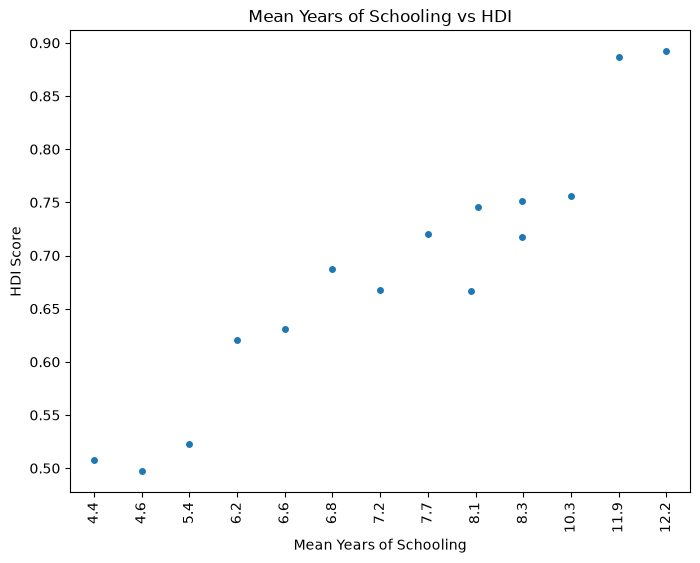

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.stripplot(
    x="Mean years of schooling",
    y="HDI",
    data=data1,
    jitter=True
)

plt.title("Mean Years of Schooling vs HDI")
plt.xlabel("Mean Years of Schooling")
plt.ylabel("HDI Score")
plt.xticks(rotation=90)

plt.show()

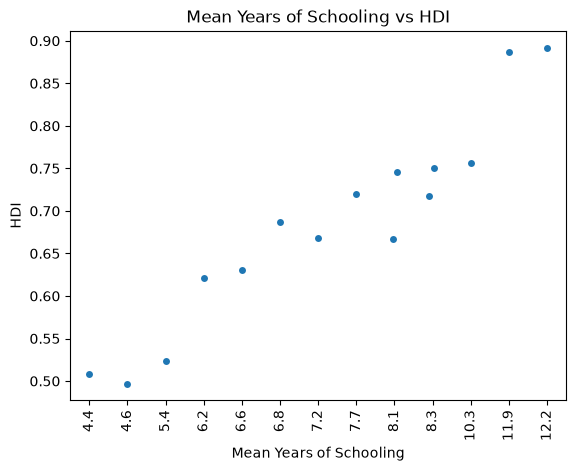

In [14]:
g = sns.stripplot(x="Mean years of schooling", y="HDI", data=data1, jitter=True)
plt.xticks(rotation=90)
plt.title("Mean Years of Schooling vs HDI")
plt.xlabel("Mean Years of Schooling")
plt.ylabel("HDI")
plt.show()

Index(['Unnamed: 0', 'Id', 'Human development groups', 'HDI', 'Life_ expectancy', 'Mean years of schooling', 'Gross national income (GNI) per capita', 'Average annual HDI growth 1990-2000', 'Average annual HDI growth 2000-2010', 'Average annual HDI growth 2010-2015', 'Average annual HDI growth 1990-2015', 'Gender Development Index value', 'Human Development Index (HDI) Female', 'Human Development Index (HDI) Male', 'Life expectancy at birth Female', 'Life expectancy at birth Male', 'Mean years of schooling Female', 'Mean years of schooling Male', 'Estimated gross national income per capita Female', 'Estimated gross national income per capita Male', 'Share of seats in parliament (% held by women)', 'Population with at least some secondary education % (2005-2015) Female', 'Population with at least some secondary education % (2005-2015) Male', 'Labour force participation rate (% ages 15 and older) Female ', 'Total Population (millions) 2015', 'Total Population (millions) 2030',
       'Po

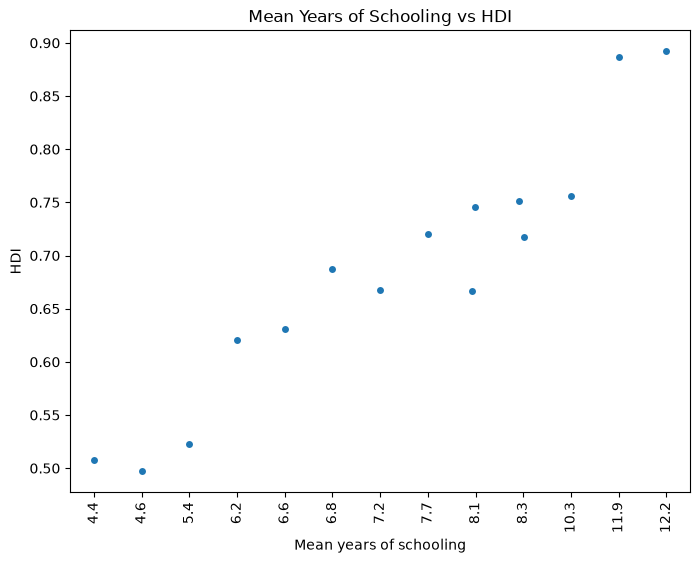

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data1 = pd.read_csv("../DataSet/Continent_HDI.csv")

# Check column names
print(data1.columns)

# Strip plot
plt.figure(figsize=(8,6))

g = sns.stripplot(
    x="Mean years of schooling",
    y="HDI",
    data=data1,
    jitter=True
)

plt.xticks(rotation=90)

# Title and labels
plt.title("Mean Years of Schooling vs HDI")
plt.xlabel("Mean years of schooling")
plt.ylabel("HDI")

plt.show()

In [16]:
print(data1.columns.tolist())

['Unnamed: 0', 'Id', 'Human development groups', 'HDI', 'Life_ expectancy', 'Mean years of schooling', 'Gross national income (GNI) per capita', 'Average annual HDI growth 1990-2000', 'Average annual HDI growth 2000-2010', 'Average annual HDI growth 2010-2015', 'Average annual HDI growth 1990-2015', 'Gender Development Index value', 'Human Development Index (HDI) Female', 'Human Development Index (HDI) Male', 'Life expectancy at birth Female', 'Life expectancy at birth Male', 'Mean years of schooling Female', 'Mean years of schooling Male', 'Estimated gross national income per capita Female', 'Estimated gross national income per capita Male', 'Share of seats in parliament (% held by women)', 'Population with at least some secondary education % (2005-2015) Female', 'Population with at least some secondary education % (2005-2015) Male', 'Labour force participation rate (% ages 15 and older) Female ', 'Total Population (millions) 2015', 'Total Population (millions) 2030', 'Population Aver

In [17]:
x="Mean years of schooling"
y="HDI"

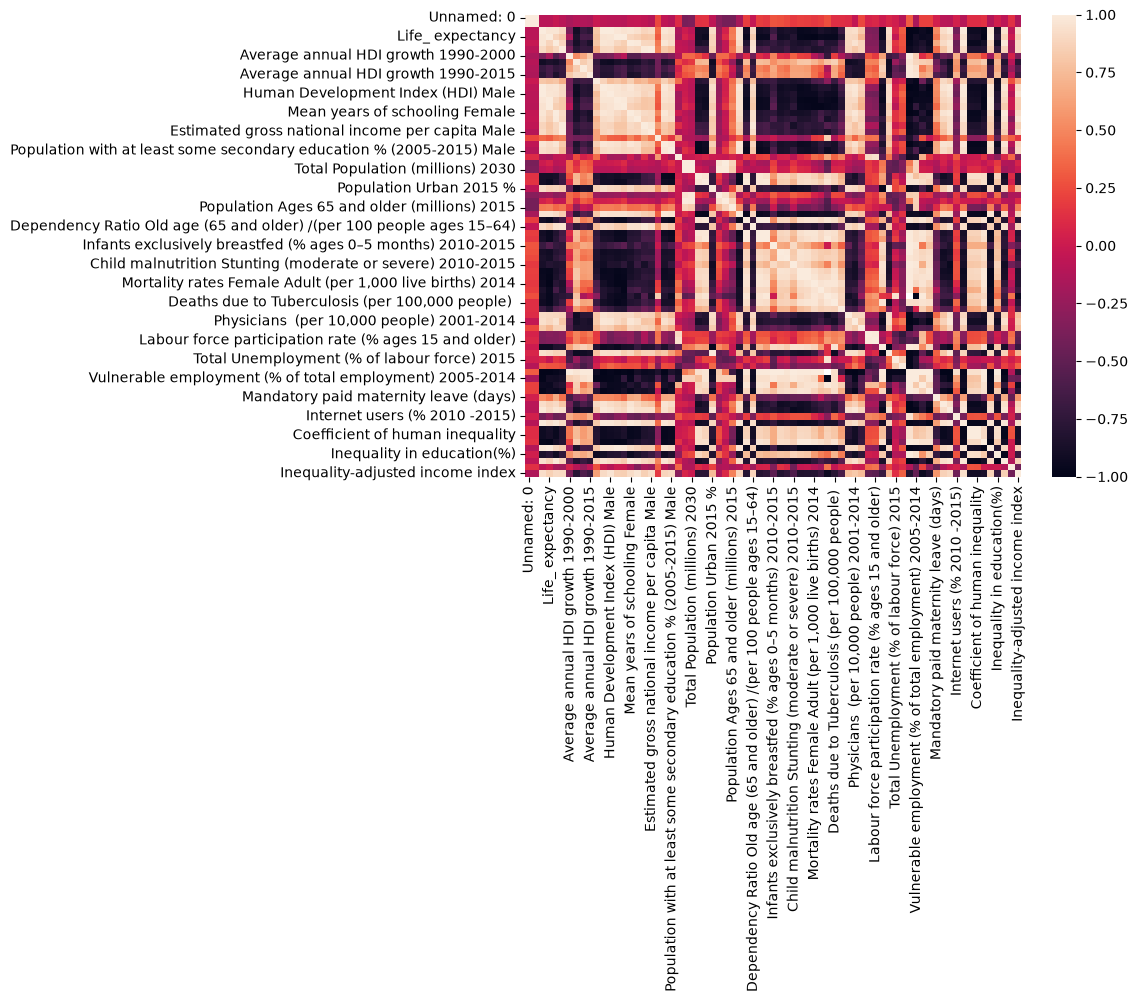

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Development = pd.read_csv("../DataSet/Continent_HDI.csv")

heat = Development.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(heat.corr(), cmap="rocket")

plt.show()

In [19]:
print(Development.columns.tolist())

['Unnamed: 0', 'Id', 'Human development groups', 'HDI', 'Life_ expectancy', 'Mean years of schooling', 'Gross national income (GNI) per capita', 'Average annual HDI growth 1990-2000', 'Average annual HDI growth 2000-2010', 'Average annual HDI growth 2010-2015', 'Average annual HDI growth 1990-2015', 'Gender Development Index value', 'Human Development Index (HDI) Female', 'Human Development Index (HDI) Male', 'Life expectancy at birth Female', 'Life expectancy at birth Male', 'Mean years of schooling Female', 'Mean years of schooling Male', 'Estimated gross national income per capita Female', 'Estimated gross national income per capita Male', 'Share of seats in parliament (% held by women)', 'Population with at least some secondary education % (2005-2015) Female', 'Population with at least some secondary education % (2005-2015) Male', 'Labour force participation rate (% ages 15 and older) Female ', 'Total Population (millions) 2015', 'Total Population (millions) 2030', 'Population Aver

In [20]:
import pandas as pd

Development = pd.read_csv("../DataSet/Continent_HDI.csv")

X = Development.iloc[:, [2,5,6,7]]
X = pd.DataFrame(X)

y = Development.iloc[:, 4].values
y = pd.DataFrame(y)

In [21]:
X = Development.iloc[:, [2,5,6,7,67]]

In [22]:
print(Development.columns.tolist())

['Unnamed: 0', 'Id', 'Human development groups', 'HDI', 'Life_ expectancy', 'Mean years of schooling', 'Gross national income (GNI) per capita', 'Average annual HDI growth 1990-2000', 'Average annual HDI growth 2000-2010', 'Average annual HDI growth 2010-2015', 'Average annual HDI growth 1990-2015', 'Gender Development Index value', 'Human Development Index (HDI) Female', 'Human Development Index (HDI) Male', 'Life expectancy at birth Female', 'Life expectancy at birth Male', 'Mean years of schooling Female', 'Mean years of schooling Male', 'Estimated gross national income per capita Female', 'Estimated gross national income per capita Male', 'Share of seats in parliament (% held by women)', 'Population with at least some secondary education % (2005-2015) Female', 'Population with at least some secondary education % (2005-2015) Male', 'Labour force participation rate (% ages 15 and older) Female ', 'Total Population (millions) 2015', 'Total Population (millions) 2030', 'Population Aver

In [23]:
X.isnull().sum()

Human development groups                  0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
Average annual HDI growth 1990-2000       0
Coefficient of human inequality           0
dtype: int64

In [24]:
for col in Development.columns:
    print(col)

Unnamed: 0
Id
Human development groups
HDI
Life_ expectancy
Mean years of schooling
Gross national income (GNI) per capita
Average annual HDI growth 1990-2000
Average annual HDI growth 2000-2010
Average annual HDI growth 2010-2015
Average annual HDI growth 1990-2015
Gender Development Index value
Human Development Index (HDI) Female
Human Development Index (HDI) Male
Life expectancy at birth Female
Life expectancy at birth Male
Mean years of schooling Female
Mean years of schooling Male
Estimated gross national income per capita Female
Estimated gross national income per capita Male
Share of seats in parliament (% held by women)
Population with at least some secondary education % (2005-2015) Female
Population with at least some secondary education % (2005-2015) Male
Labour force participation rate (% ages 15 and older) Female 
Total Population (millions) 2015
Total Population (millions) 2030
Population Average annual growth 2000/2005 (%) 
Population Average annual growth 2010/2015 (%) 

In [25]:
import pandas as pd

Development = pd.read_csv("../DataSet/Continent_HDI.csv")

print(Development.columns.tolist())

['Unnamed: 0', 'Id', 'Human development groups', 'HDI', 'Life_ expectancy', 'Mean years of schooling', 'Gross national income (GNI) per capita', 'Average annual HDI growth 1990-2000', 'Average annual HDI growth 2000-2010', 'Average annual HDI growth 2010-2015', 'Average annual HDI growth 1990-2015', 'Gender Development Index value', 'Human Development Index (HDI) Female', 'Human Development Index (HDI) Male', 'Life expectancy at birth Female', 'Life expectancy at birth Male', 'Mean years of schooling Female', 'Mean years of schooling Male', 'Estimated gross national income per capita Female', 'Estimated gross national income per capita Male', 'Share of seats in parliament (% held by women)', 'Population with at least some secondary education % (2005-2015) Female', 'Population with at least some secondary education % (2005-2015) Male', 'Labour force participation rate (% ages 15 and older) Female ', 'Total Population (millions) 2015', 'Total Population (millions) 2030', 'Population Aver

In [26]:
import pandas as pd

Development = pd.read_csv("../DataSet/Continent_HDI.csv")

X = Development.iloc[:, [2,4,5,6,7]]

X = pd.DataFrame(X)

print(X.isnull().sum())

Human development groups                  0
Life_ expectancy                          0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
Average annual HDI growth 1990-2000       0
dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

In [28]:
WellBeing = pd.read_csv("../DataSet/Continent_HDI.csv")

In [29]:
import os

print(os.getcwd())

c:\Users\DELL\OneDrive\Desktop\Human Development Index\Training


In [30]:

import os

print(os.listdir())

['HumDevIndex.ipynb', 'well_being_framework.py']


In [31]:
import os

print(os.listdir(".."))

['dataset', 'Flask', 'ML-Human Development Inde', 'templates', 'Training']


In [32]:
import os
import pandas as pd

for root, dirs, files in os.walk(".."):
    if "Continent_HDI.csv" in files:
        path = os.path.join(root, "Continent_HDI.csv")
        print("Found:", path)
        WellBeing = pd.read_csv(path)
        break

print(WellBeing.head())

Found: ..\dataset\Continent_HDI.csv
   Unnamed: 0  Id     Human development groups    HDI  Life_ expectancy  Mean years of schooling  Gross national income (GNI) per capita  Average annual HDI growth 1990-2000  Average annual HDI growth 2000-2010  Average annual HDI growth 2010-2015  Average annual HDI growth 1990-2015  Gender Development Index value  Human Development Index (HDI) Female  Human Development Index (HDI) Male  Life expectancy at birth Female  Life expectancy at birth Male  Mean years of schooling Female  Mean years of schooling Male  Estimated gross national income per capita Female  Estimated gross national income per capita Male  Share of seats in parliament (% held by women)  Population with at least some secondary education % (2005-2015) Female  Population with at least some secondary education % (2005-2015) Male  Labour force participation rate (% ages 15 and older) Female   Total Population (millions) 2015  Total Population (millions) 2030  Population Average annual

In [33]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\DELL\OneDrive\Desktop\Human Development Index\Training
['HumDevIndex.ipynb', 'well_being_framework.py']


In [34]:
import os

print("Current directory:", os.getcwd())

Current directory: c:\Users\DELL\OneDrive\Desktop\Human Development Index\Training


In [35]:
import os

for root, dirs, files in os.walk(os.getcwd()):
    print(root)
    for file in files:
        print("   ", file)

c:\Users\DELL\OneDrive\Desktop\Human Development Index\Training
    HumDevIndex.ipynb
    well_being_framework.py


In [36]:
print(type(model))

NameError: name 'model' is not defined

In [ ]:
WellBeing = pd.read_csv("../dataset/Continent_HDI.csv")

In [ ]:
print(WellBeing.columns)

Index(['Unnamed: 0', 'Id', 'Human development groups', 'HDI', 'Life_ expectancy', 'Mean years of schooling', 'Gross national income (GNI) per capita', 'Average annual HDI growth 1990-2000', 'Average annual HDI growth 2000-2010', 'Average annual HDI growth 2010-2015', 'Average annual HDI growth 1990-2015', 'Gender Development Index value', 'Human Development Index (HDI) Female', 'Human Development Index (HDI) Male', 'Life expectancy at birth Female', 'Life expectancy at birth Male', 'Mean years of schooling Female', 'Mean years of schooling Male', 'Estimated gross national income per capita Female', 'Estimated gross national income per capita Male', 'Share of seats in parliament (% held by women)', 'Population with at least some secondary education % (2005-2015) Female', 'Population with at least some secondary education % (2005-2015) Male', 'Labour force participation rate (% ages 15 and older) Female ', 'Total Population (millions) 2015', 'Total Population (millions) 2030',
       'Po

In [ ]:
X = WellBeing.drop("HDI", axis=1)
y = WellBeing["HDI"]

In [ ]:
print(WellBeing.columns.tolist())

['Unnamed: 0', 'Id', 'Human development groups', 'HDI', 'Life_ expectancy', 'Mean years of schooling', 'Gross national income (GNI) per capita', 'Average annual HDI growth 1990-2000', 'Average annual HDI growth 2000-2010', 'Average annual HDI growth 2010-2015', 'Average annual HDI growth 1990-2015', 'Gender Development Index value', 'Human Development Index (HDI) Female', 'Human Development Index (HDI) Male', 'Life expectancy at birth Female', 'Life expectancy at birth Male', 'Mean years of schooling Female', 'Mean years of schooling Male', 'Estimated gross national income per capita Female', 'Estimated gross national income per capita Male', 'Share of seats in parliament (% held by women)', 'Population with at least some secondary education % (2005-2015) Female', 'Population with at least some secondary education % (2005-2015) Male', 'Labour force participation rate (% ages 15 and older) Female ', 'Total Population (millions) 2015', 'Total Population (millions) 2030', 'Population Aver

In [ ]:
print(WellBeing.head())
print(WellBeing.info())

   Unnamed: 0  Id     Human development groups    HDI  Life_ expectancy  Mean years of schooling  Gross national income (GNI) per capita  Average annual HDI growth 1990-2000  Average annual HDI growth 2000-2010  Average annual HDI growth 2010-2015  Average annual HDI growth 1990-2015  Gender Development Index value  Human Development Index (HDI) Female  Human Development Index (HDI) Male  Life expectancy at birth Female  Life expectancy at birth Male  Mean years of schooling Female  Mean years of schooling Male  Estimated gross national income per capita Female  Estimated gross national income per capita Male  Share of seats in parliament (% held by women)  Population with at least some secondary education % (2005-2015) Female  Population with at least some secondary education % (2005-2015) Male  Labour force participation rate (% ages 15 and older) Female   Total Population (millions) 2015  Total Population (millions) 2030  Population Average annual growth 2000/2005 (%)   \
0         

In [ ]:
import pickle

filename = "wellbeing_model.pkl"

with open(filename, "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully as", filename)

Model saved successfully as wellbeing_model.pkl


In [ ]:
import pickle

with open("wellbeing_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully")

Model loaded successfully


In [1]:
import shutil
import os
import sys

cache_path = os.path.join(os.path.dirname(os.path.abspath("well_being_framework.py")), "__pycache__")
if os.path.exists(cache_path):
    shutil.rmtree(cache_path)
    print("Deleted __pycache__")

modules_to_remove = [k for k in sys.modules.keys() if "well_being" in k]
for mod in modules_to_remove:
    del sys.modules[mod]

from well_being_framework import WellBeingAssessor, WellBeingTracker
print("Import successful!")

Import successful!


In [2]:
# Test the framework
assessor = WellBeingAssessor()
profile = assessor.full_assessment(
    person_id="TEST_USER",
    date="2026-07-10",
    bmi=23.5,
    sleep_hours=7.5,
    exercise_minutes_week=180,
    steps_per_day=9500,
    stress_level=4,
    anxiety_score=4,
    life_satisfaction=8,
    close_relationships=5,
    social_frequency=3,
    savings_rate=0.20,
    debt_to_income=0.25,
    emergency_months=6,
    goal_clarity=8,
    values_alignment=8
)

print(f"Score: {profile.composite_score:.1f}/100")
print(f"Status: {profile.overall_risk.value}")
print(profile.summary)

Score: 72.5/100
Status: good
Overall well-being score: 72.5/100 (GOOD). Strongest area: Physical (99.2). Area needing attention: Financial (52.2).


In [3]:
# Create assessor
assessor = WellBeingAssessor()

# Run assessment
profile = assessor.full_assessment(
    person_id="USER_001",
    date="2026-07-10",
    bmi=24.5,
    sleep_hours=7,
    exercise_minutes_week=120,
    steps_per_day=8000,
    stress_level=5,
    anxiety_score=6,
    life_satisfaction=7,
    close_relationships=4,
    social_frequency=2,
    savings_rate=0.15,
    debt_to_income=0.30,
    emergency_months=3,
    goal_clarity=6,
    values_alignment=7
)

# View results
print(f"Composite Score: {profile.composite_score:.1f}/100")
print(f"Status: {profile.overall_risk.value.upper()}")
print(profile.summary)
print(profile.to_json())

Composite Score: 66.4/100
Status: GOOD
Overall well-being score: 66.4/100 (GOOD). Strongest area: Physical (92.0). Area needing attention: Financial (46.7).
{
  "person_id": "USER_001",
  "assessment_date": "2026-07-10",
  "composite_score": 66.41,
  "overall_risk": "good",
  "summary": "Overall well-being score: 66.4/100 (GOOD). Strongest area: Physical (92.0). Area needing attention: Financial (46.7).",
  "dimensions": {
    "physical": {
      "score": 92.0,
      "risk": "excellent",
      "metrics": [
        {
          "name": "BMI",
          "score": 100,
          "weight": 0.25,
          "raw_value": 24.5,
          "unit": "kg/m2"
        },
        {
          "name": "Sleep Quality",
          "score": 100,
          "weight": 0.25,
          "raw_value": 7,
          "unit": "hours"
        },
        {
          "name": "Physical Activity",
          "score": 80.0,
          "weight": 0.25,
          "raw_value": 120,
          "unit": "min/week"
        },
        {
 

In [4]:

tracker = WellBeingTracker()
tracker.add_assessment(profile)
print(tracker.generate_report())

WELL-BEING ASSESSMENT REPORT
Person ID: USER_001
Assessment Date: 2026-07-10
Total Assessments: 1

COMPOSITE SCORE: 66.4/100
OVERALL STATUS: GOOD

------------------------------------------------------------
DIMENSIONAL ANALYSIS
------------------------------------------------------------

PHYSICAL
  Score: 92.0/100 | Status: EXCELLENT
  Metrics:
    - BMI: 100.0 (weight: 0.25)
    - Sleep Quality: 100.0 (weight: 0.25)
    - Physical Activity: 80.0 (weight: 0.25)
    - Daily Movement: 80.0 (weight: 0.15)
    - Health Conditions: 100.0 (weight: 0.1)
  Recommendations:
    -> Increase to at least 150 min/week of moderate exercise

MENTAL
  Score: 65.3/100 | Status: GOOD
  Metrics:
    - Stress Management: 50.0 (weight: 0.25)
    - Anxiety Level: 71.4 (weight: 0.2)
    - Mood Stability: 85.2 (weight: 0.2)
    - Mindfulness Practice: 50.0 (weight: 0.15)
    - Life Satisfaction: 70.0 (weight: 0.2)
  Recommendations:
    -> Continue mental wellness practices; consider journaling

SOCIAL
  Sc

In [5]:
assessor = WellBeingAssessor()

profile = assessor.full_assessment(
    person_id="USER_001",
    date="2026-07-10",
    bmi=24.5,
    sleep_hours=7.5,
    exercise_minutes_week=180,
    steps_per_day=9500,
    stress_level=4,
    anxiety_score=4,
    life_satisfaction=8,
    close_relationships=5,
    social_frequency=3,
    savings_rate=0.20,
    debt_to_income=0.25,
    emergency_months=6,
    goal_clarity=8,
    values_alignment=8
)

print(f"Score: {profile.composite_score:.1f}/100")
print(profile.to_json())

Score: 72.5/100
{
  "person_id": "USER_001",
  "assessment_date": "2026-07-10",
  "composite_score": 72.47,
  "overall_risk": "good",
  "summary": "Overall well-being score: 72.5/100 (GOOD). Strongest area: Physical (99.2). Area needing attention: Financial (52.2).",
  "dimensions": {
    "physical": {
      "score": 99.25,
      "risk": "excellent",
      "metrics": [
        {
          "name": "BMI",
          "score": 100,
          "weight": 0.25,
          "raw_value": 24.5,
          "unit": "kg/m2"
        },
        {
          "name": "Sleep Quality",
          "score": 100,
          "weight": 0.25,
          "raw_value": 7.5,
          "unit": "hours"
        },
        {
          "name": "Physical Activity",
          "score": 100,
          "weight": 0.25,
          "raw_value": 180,
          "unit": "min/week"
        },
        {
          "name": "Daily Movement",
          "score": 95.0,
          "weight": 0.15,
          "raw_value": 9500,
          "unit": "steps

In [10]:
import json
import numpy as np
from dataclasses import dataclass
from typing import Dict, List, Optional
from enum import Enum

class WellBeingDimension(Enum):
    PHYSICAL = "physical"
    MENTAL = "mental"
    SOCIAL = "social"
    FINANCIAL = "financial"
    ENVIRONMENTAL = "environmental"
    PURPOSE = "purpose"
    LEARNING = "learning"

class RiskLevel(Enum):
    CRITICAL = "critical"
    LOW = "low"
    MODERATE = "moderate"
    GOOD = "good"
    EXCELLENT = "excellent"

@dataclass
class MetricScore:
    name: str
    score: float
    weight: float
    description: str
    raw_value: Optional[float] = None
    unit: Optional[str] = None

    @property
    def weighted_score(self) -> float:
        return self.score * self.weight

@dataclass
class DimensionResult:
    dimension: WellBeingDimension
    metrics: List[MetricScore]
    overall_score: float
    risk_level: RiskLevel
    recommendations: List[str]

@dataclass
class WellBeingProfile:
    person_id: str
    assessment_date: str
    dimensions: Dict[WellBeingDimension, DimensionResult]
    composite_score: float
    overall_risk: RiskLevel
    summary: str
    action_plan: List[str]
    ml_prediction: Optional[float] = None

    def to_dict(self) -> dict:
        return {
            "person_id": self.person_id,
            "assessment_date": self.assessment_date,
            "composite_score": round(self.composite_score, 2),
            "ml_prediction": self.ml_prediction,
            "overall_risk": self.overall_risk.value,
            "summary": self.summary,
            "dimensions": {
                dim.value: {
                    "score": round(res.overall_score, 2),
                    "risk": res.risk_level.value,
                    "metrics": [
                        {
                            "name": m.name,
                            "score": round(m.score, 2),
                            "weight": m.weight,
                            "raw_value": m.raw_value,
                            "unit": m.unit
                        } for m in res.metrics
                    ],
                    "recommendations": res.recommendations
                }
                for dim, res in self.dimensions.items()
            },
            "action_plan": self.action_plan
        }

    def to_json(self, indent: int = 2) -> str:
        return json.dumps(self.to_dict(), indent=indent)

class ScoringEngine:
    @staticmethod
    def normalize(value: float, min_val: float, max_val: float, invert: bool = False) -> float:
        if max_val == min_val:
            return 50
        normalized = (value - min_val) / (max_val - min_val) * 100
        normalized = max(0, min(100, normalized))
        return 100 - normalized if invert else normalized

    @staticmethod
    def bmi_score(bmi: float) -> float:
        if 18.5 <= bmi <= 24.9:
            return 100
        elif bmi < 18.5:
            return ScoringEngine.normalize(bmi, 10, 18.5, invert=True)
        else:
            return ScoringEngine.normalize(bmi, 24.9, 40, invert=True)

    @staticmethod
    def sleep_score(hours: float) -> float:
        if 7 <= hours <= 9:
            return 100
        elif hours < 7:
            return ScoringEngine.normalize(hours, 0, 7)
        else:
            return ScoringEngine.normalize(hours, 9, 12, invert=True)

    @staticmethod
    def risk_level(score: float) -> RiskLevel:
        if score >= 81: return RiskLevel.EXCELLENT
        elif score >= 61: return RiskLevel.GOOD
        elif score >= 41: return RiskLevel.MODERATE
        elif score >= 21: return RiskLevel.LOW
        else: return RiskLevel.CRITICAL

class WellBeingAssessor:
    def __init__(self):
        self.scorer = ScoringEngine()
        self.dimension_weights = {
            WellBeingDimension.PHYSICAL: 0.20,
            WellBeingDimension.MENTAL: 0.20,
            WellBeingDimension.SOCIAL: 0.15,
            WellBeingDimension.FINANCIAL: 0.15,
            WellBeingDimension.ENVIRONMENTAL: 0.10,
            WellBeingDimension.PURPOSE: 0.10,
            WellBeingDimension.LEARNING: 0.10,
        }

    def assess_physical(self, bmi: float, sleep_hours: float, exercise_minutes_week: float, steps_per_day: float, chronic_conditions: int = 0) -> DimensionResult:
        metrics = [
            MetricScore("BMI", self.scorer.bmi_score(bmi), 0.25, "Body Mass Index", bmi, "kg/m2"),
            MetricScore("Sleep Quality", self.scorer.sleep_score(sleep_hours), 0.25, "Average nightly sleep", sleep_hours, "hours"),
            MetricScore("Physical Activity", min(100, exercise_minutes_week / 150 * 100), 0.25, "Weekly exercise minutes", exercise_minutes_week, "min/week"),
            MetricScore("Daily Movement", min(100, steps_per_day / 10000 * 100), 0.15, "Average daily steps", steps_per_day, "steps"),
            MetricScore("Health Conditions", max(0, 100 - chronic_conditions * 20), 0.10, "Number of chronic conditions", chronic_conditions, "count")
        ]
        score = sum(m.weighted_score for m in metrics)
        risk = self.scorer.risk_level(score)
        recommendations = []
        if bmi < 18.5 or bmi > 24.9:
            recommendations.append("Consult a nutritionist for weight management")
        if sleep_hours < 7:
            recommendations.append("Establish a consistent sleep schedule; aim for 7-9 hours")
        if exercise_minutes_week < 150:
            recommendations.append("Increase to at least 150 min/week of moderate exercise")
        if steps_per_day < 7000:
            recommendations.append("Aim for 7,000-10,000 steps daily")
        if not recommendations:
            recommendations.append("Maintain current healthy lifestyle habits")
        return DimensionResult(WellBeingDimension.PHYSICAL, metrics, score, risk, recommendations)

    def assess_mental(self, stress_level: float, anxiety_score: float, depression_score: float, mindfulness_minutes: float, life_satisfaction: float) -> DimensionResult:
        metrics = [
            MetricScore("Stress Management", self.scorer.normalize(stress_level, 10, 0), 0.25, "Perceived stress scale (0-10)", stress_level, "0-10"),
            MetricScore("Anxiety Level", self.scorer.normalize(anxiety_score, 21, 0), 0.20, "GAD-7 anxiety score", anxiety_score, "0-21"),
            MetricScore("Mood Stability", self.scorer.normalize(depression_score, 27, 0), 0.20, "PHQ-9 depression score", depression_score, "0-27"),
            MetricScore("Mindfulness Practice", min(100, mindfulness_minutes / 20 * 100), 0.15, "Daily mindfulness minutes", mindfulness_minutes, "min/day"),
            MetricScore("Life Satisfaction", life_satisfaction * 10, 0.20, "Life satisfaction (0-10)", life_satisfaction, "0-10")
        ]
        score = sum(m.weighted_score for m in metrics)
        risk = self.scorer.risk_level(score)
        recommendations = []
        if stress_level > 6:
            recommendations.append("Practice stress reduction techniques (breathing, meditation)")
        if anxiety_score > 10:
            recommendations.append("Consider speaking with a mental health professional")
        if depression_score > 10:
            recommendations.append("Seek professional support for mood management")
        if mindfulness_minutes < 10:
            recommendations.append("Start with 10 minutes daily mindfulness practice")
        if not recommendations:
            recommendations.append("Continue mental wellness practices; consider journaling")
        return DimensionResult(WellBeingDimension.MENTAL, metrics, score, risk, recommendations)

    def assess_social(self, close_relationships: int, social_frequency: float, community_belonging: float, support_network_size: int, loneliness_score: float) -> DimensionResult:
        metrics = [
            MetricScore("Close Relationships", min(100, close_relationships / 5 * 100), 0.25, "Number of close relationships", close_relationships, "count"),
            MetricScore("Social Engagement", min(100, social_frequency / 3 * 100), 0.20, "Social activities per week", social_frequency, "times/week"),
            MetricScore("Community Belonging", community_belonging * 10, 0.20, "Sense of belonging (0-10)", community_belonging, "0-10"),
            MetricScore("Support Network", min(100, support_network_size / 10 * 100), 0.20, "People you can rely on", support_network_size, "count"),
            MetricScore("Loneliness", self.scorer.normalize(loneliness_score, 10, 0), 0.15, "Loneliness scale (0-10)", loneliness_score, "0-10")
        ]
        score = sum(m.weighted_score for m in metrics)
        risk = self.scorer.risk_level(score)
        recommendations = []
        if close_relationships < 3:
            recommendations.append("Invest time in building 2-3 deep relationships")
        if social_frequency < 2:
            recommendations.append("Schedule at least 2 social activities per week")
        if community_belonging < 5:
            recommendations.append("Join a community group or volunteer organization")
        if loneliness_score > 5:
            recommendations.append("Reach out to existing contacts; consider support groups")
        if not recommendations:
            recommendations.append("Nurture existing relationships; mentor someone new")
        return DimensionResult(WellBeingDimension.SOCIAL, metrics, score, risk, recommendations)

    def assess_financial(self, savings_rate: float, debt_to_income: float, emergency_months: float, income_stability: float, financial_literacy: float) -> DimensionResult:
        metrics = [
            MetricScore("Savings Rate", min(100, savings_rate * 5), 0.25, "Percentage of income saved", savings_rate, "%"),
            MetricScore("Debt Burden", self.scorer.normalize(debt_to_income, 0.5, 0, invert=True), 0.25, "Debt-to-income ratio", debt_to_income, "ratio"),
            MetricScore("Emergency Fund", min(100, emergency_months * 20), 0.20, "Months of expenses covered", emergency_months, "months"),
            MetricScore("Income Stability", income_stability * 10, 0.15, "Income stability (0-10)", income_stability, "0-10"),
            MetricScore("Financial Literacy", financial_literacy * 10, 0.15, "Financial knowledge (0-10)", financial_literacy, "0-10")
        ]
        score = sum(m.weighted_score for m in metrics)
        risk = self.scorer.risk_level(score)
        recommendations = []
        if savings_rate < 0.15:
            recommendations.append("Aim to save at least 15-20% of income")
        if debt_to_income > 0.36:
            recommendations.append("Create a debt reduction plan; prioritize high-interest debt")
        if emergency_months < 3:
            recommendations.append("Build emergency fund to cover 3-6 months of expenses")
        if financial_literacy < 6:
            recommendations.append("Take a financial literacy course or read personal finance books")
        if not recommendations:
            recommendations.append("Consider investment diversification and retirement planning")
        return DimensionResult(WellBeingDimension.FINANCIAL, metrics, score, risk, recommendations)

    def assess_environmental(self, air_quality_index: float, green_space_access: float, housing_satisfaction: float, commute_quality: float, noise_level: float) -> DimensionResult:
        metrics = [
            MetricScore("Air Quality", self.scorer.normalize(air_quality_index, 200, 0), 0.25, "Local AQI (lower is better)", air_quality_index, "AQI"),
            MetricScore("Green Access", min(100, green_space_access / 30 * 100), 0.20, "Minutes to nearest green space", green_space_access, "min"),
            MetricScore("Housing Quality", housing_satisfaction * 10, 0.25, "Housing satisfaction (0-10)", housing_satisfaction, "0-10"),
            MetricScore("Commute Experience", commute_quality * 10, 0.20, "Commute satisfaction (0-10)", commute_quality, "0-10"),
            MetricScore("Noise Exposure", self.scorer.normalize(noise_level, 80, 30, invert=True), 0.10, "Average noise level (dB)", noise_level, "dB")
        ]
        score = sum(m.weighted_score for m in metrics)
        risk = self.scorer.risk_level(score)
        recommendations = []
        if air_quality_index > 100:
            recommendations.append("Use air purifiers; check air quality before outdoor activities")
        if green_space_access > 15:
            recommendations.append("Find closer green spaces or create indoor plant environment")
        if housing_satisfaction < 6:
            recommendations.append("Identify housing improvements or consider relocation")
        if commute_quality < 5:
            recommendations.append("Explore remote work options or alternative commute methods")
        if not recommendations:
            recommendations.append("Maintain environmental wellness; add plants to living space")
        return DimensionResult(WellBeingDimension.ENVIRONMENTAL, metrics, score, risk, recommendations)

    def assess_purpose(self, goal_clarity: float, values_alignment: float, contribution_sense: float, progress_toward_goals: float, meaning_in_work: float) -> DimensionResult:
        metrics = [
            MetricScore("Goal Clarity", goal_clarity * 10, 0.25, "Clarity of life goals (0-10)", goal_clarity, "0-10"),
            MetricScore("Values Alignment", values_alignment * 10, 0.25, "Actions aligned with values (0-10)", values_alignment, "0-10"),
            MetricScore("Contribution", contribution_sense * 10, 0.20, "Sense of contributing to others (0-10)", contribution_sense, "0-10"),
            MetricScore("Goal Progress", progress_toward_goals * 10, 0.15, "Progress toward goals (0-10)", progress_toward_goals, "0-10"),
            MetricScore("Work Meaning", meaning_in_work * 10, 0.15, "Meaning derived from work (0-10)", meaning_in_work, "0-10")
        ]
        score = sum(m.weighted_score for m in metrics)
        risk = self.scorer.risk_level(score)
        recommendations = []
        if goal_clarity < 5:
            recommendations.append("Write a personal mission statement; define 1-year goals")
        if values_alignment < 6:
            recommendations.append("Audit weekly activities against core values")
        if contribution_sense < 5:
            recommendations.append("Volunteer or mentor to increase sense of contribution")
        if progress_toward_goals < 5:
            recommendations.append("Break goals into monthly milestones; track progress")
        if not recommendations:
            recommendations.append("Set stretch goals; share your purpose with others")
        return DimensionResult(WellBeingDimension.PURPOSE, metrics, score, risk, recommendations)

    def assess_learning(self, new_skills_monthly: float, reading_hours: float, curiosity_level: float, skill_diversity: float, learning_satisfaction: float) -> DimensionResult:
        metrics = [
            MetricScore("Skill Acquisition", min(100, new_skills_monthly / 2 * 100), 0.25, "New skills learned per month", new_skills_monthly, "count/month"),
            MetricScore("Reading Habit", min(100, reading_hours / 10 * 100), 0.20, "Weekly reading hours", reading_hours, "hours/week"),
            MetricScore("Curiosity", curiosity_level * 10, 0.20, "Curiosity level (0-10)", curiosity_level, "0-10"),
            MetricScore("Skill Diversity", min(100, skill_diversity / 5 * 100), 0.20, "Number of distinct skill areas", skill_diversity, "count"),
            MetricScore("Growth Satisfaction", learning_satisfaction * 10, 0.15, "Satisfaction with personal growth (0-10)", learning_satisfaction, "0-10")
        ]
        score = sum(m.weighted_score for m in metrics)
        risk = self.scorer.risk_level(score)
        recommendations = []
        if new_skills_monthly < 1:
            recommendations.append("Commit to learning one new skill per month")
        if reading_hours < 3:
            recommendations.append("Start with 30 minutes of reading daily")
        if curiosity_level < 5:
            recommendations.append("Explore new topics outside your comfort zone")
        if skill_diversity < 3:
            recommendations.append("Learn skills from different domains (technical, creative, social)")
        if not recommendations:
            recommendations.append("Teach what you have learned; start a learning project")
        return DimensionResult(WellBeingDimension.LEARNING, metrics, score, risk, recommendations)

    def full_assessment(self, person_id: str, date: str, ml_prediction: Optional[float] = None, **kwargs) -> WellBeingProfile:
        dimensions = {}
        dimensions[WellBeingDimension.PHYSICAL] = self.assess_physical(
            kwargs.get('bmi', 24), kwargs.get('sleep_hours', 7), kwargs.get('exercise_minutes_week', 150),
            kwargs.get('steps_per_day', 8000), kwargs.get('chronic_conditions', 0)
        )
        dimensions[WellBeingDimension.MENTAL] = self.assess_mental(
            kwargs.get('stress_level', 5), kwargs.get('anxiety_score', 5), kwargs.get('depression_score', 4),
            kwargs.get('mindfulness_minutes', 10), kwargs.get('life_satisfaction', 7)
        )
        dimensions[WellBeingDimension.SOCIAL] = self.assess_social(
            kwargs.get('close_relationships', 4), kwargs.get('social_frequency', 2), kwargs.get('community_belonging', 6),
            kwargs.get('support_network_size', 5), kwargs.get('loneliness_score', 4)
        )
        dimensions[WellBeingDimension.FINANCIAL] = self.assess_financial(
            kwargs.get('savings_rate', 0.15), kwargs.get('debt_to_income', 0.30), kwargs.get('emergency_months', 4),
            kwargs.get('income_stability', 7), kwargs.get('financial_literacy', 6)
        )
        dimensions[WellBeingDimension.ENVIRONMENTAL] = self.assess_environmental(
            kwargs.get('air_quality_index', 50), kwargs.get('green_space_access', 10), kwargs.get('housing_satisfaction', 7),
            kwargs.get('commute_quality', 6), kwargs.get('noise_level', 50)
        )
        dimensions[WellBeingDimension.PURPOSE] = self.assess_purpose(
            kwargs.get('goal_clarity', 6), kwargs.get('values_alignment', 7), kwargs.get('contribution_sense', 6),
            kwargs.get('progress_toward_goals', 5), kwargs.get('meaning_in_work', 6)
        )
        dimensions[WellBeingDimension.LEARNING] = self.assess_learning(
            kwargs.get('new_skills_monthly', 1), kwargs.get('reading_hours', 5), kwargs.get('curiosity_level', 7),
            kwargs.get('skill_diversity', 4), kwargs.get('learning_satisfaction', 7)
        )
        composite = sum(dimensions[dim].overall_score * self.dimension_weights[dim] for dim in WellBeingDimension)
        overall_risk = self.scorer.risk_level(composite)
        lowest_dim = min(dimensions.items(), key=lambda x: x[1].overall_score)
        highest_dim = max(dimensions.items(), key=lambda x: x[1].overall_score)
        summary = f"Overall well-being score: {composite:.1f}/100 ({overall_risk.value.upper()}). Strongest area: {highest_dim[0].value.title()} ({highest_dim[1].overall_score:.1f}). Area needing attention: {lowest_dim[0].value.title()} ({lowest_dim[1].overall_score:.1f})."
        if ml_prediction is not None:
            summary += f" ML model prediction: {ml_prediction:.3f}."
        action_plan = []
        for dim, result in sorted(dimensions.items(), key=lambda x: x[1].overall_score)[:3]:
            if result.risk_level in [RiskLevel.CRITICAL, RiskLevel.LOW, RiskLevel.MODERATE]:
                action_plan.append(f"[{dim.value.title()}] {result.recommendations[0]}")
        return WellBeingProfile(person_id, date, dimensions, composite, overall_risk, summary, action_plan, ml_prediction)

class WellBeingTracker:
    def __init__(self):
        self.history: List[WellBeingProfile] = []

    def add_assessment(self, profile: WellBeingProfile):
        self.history.append(profile)

    def trend_analysis(self, dimension: WellBeingDimension) -> Dict:
        if len(self.history) < 2:
            return {"error": "Need at least 2 assessments for trend analysis"}
        scores = [p.dimensions[dimension].overall_score for p in self.history]
        dates = [p.assessment_date for p in self.history]
        if len(scores) >= 2:
            slope = (scores[-1] - scores[0]) / (len(scores) - 1)
            trend = "improving" if slope > 1 else "declining" if slope < -1 else "stable"
        else:
            slope = 0
            trend = "stable"
        return {"dimension": dimension.value, "scores": scores, "dates": dates, "trend": trend, "slope": round(slope, 2), "change": round(scores[-1] - scores[0], 1), "current": round(scores[-1], 1)}

    def generate_report(self) -> str:
        if not self.history:
            return "No assessment history available."
        latest = self.history[-1]
        report = []
        report.append("=" * 60)
        report.append("WELL-BEING ASSESSMENT REPORT")
        report.append("=" * 60)
        report.append(f"Person ID: {latest.person_id}")
        report.append(f"Assessment Date: {latest.assessment_date}")
        report.append(f"Total Assessments: {len(self.history)}")
        report.append("")
        report.append(f"COMPOSITE SCORE: {latest.composite_score:.1f}/100")
        if latest.ml_prediction is not None:
            report.append(f"ML PREDICTION: {latest.ml_prediction:.3f}")
        report.append(f"OVERALL STATUS: {latest.overall_risk.value.upper()}")
        report.append("")
        report.append("-" * 60)
        report.append("DIMENSIONAL ANALYSIS")
        report.append("-" * 60)
        for dim in WellBeingDimension:
            result = latest.dimensions[dim]
            report.append(f"\n{dim.value.upper()}")
            report.append(f"  Score: {result.overall_score:.1f}/100 | Status: {result.risk_level.value.upper()}")
            report.append(f"  Metrics:")
            for m in result.metrics:
                report.append(f"    - {m.name}: {m.score:.1f} (weight: {m.weight})")
            report.append(f"  Recommendations:")
            for rec in result.recommendations:
                report.append(f"    -> {rec}")
        report.append("")
        report.append("-" * 60)
        report.append("PRIORITY ACTION PLAN")
        report.append("-" * 60)
        for i, action in enumerate(latest.action_plan, 1):
            report.append(f"{i}. {action}")
        if len(self.history) >= 2:
            report.append("")
            report.append("-" * 60)
            report.append("TREND ANALYSIS")
            report.append("-" * 60)
            for dim in WellBeingDimension:
                trend = self.trend_analysis(dim)
                report.append(f"{dim.value.title()}: {trend['trend'].upper()} (change: {trend['change']:+.1f})")
        return "\n".join(report)

class MLWellBeingBridge:
    @staticmethod
    def ml_to_framework_score(ml_value: float, scale: str = "0-1") -> float:
        if scale == "0-1":
            return ml_value * 100
        return ml_value

    @staticmethod
    def compare_ml_vs_framework(ml_prediction: float, framework_score: float) -> Dict:
        ml_100 = ml_prediction * 100 if ml_prediction <= 1 else ml_prediction
        diff = abs(ml_100 - framework_score)
        agreement = "high" if diff < 10 else "moderate" if diff < 20 else "low"
        return {
            "ml_prediction": round(ml_prediction, 3),
            "framework_score": round(framework_score, 1),
            "difference": round(diff, 1),
            "agreement": agreement
        }

    @staticmethod
    def generate_ml_features(profile: WellBeingProfile) -> List[float]:
        features = []
        for dim in WellBeingDimension:
            features.append(profile.dimensions[dim].overall_score)
        features.append(profile.composite_score)
        return features

# Now use it directly
assessor = WellBeingAssessor()

profile = assessor.full_assessment(
    person_id="USER_001",
    date="2026-07-10",
    ml_prediction=0.727,
    bmi=24.5,
    sleep_hours=7.5,
    exercise_minutes_week=180,
    steps_per_day=9500,
    stress_level=4,
    anxiety_score=4,
    life_satisfaction=8,
    close_relationships=5,
    social_frequency=3,
    savings_rate=0.20,
    debt_to_income=0.25,
    emergency_months=6,
    goal_clarity=8,
    values_alignment=8
)

print(f"Framework Score: {profile.composite_score:.1f}/100")
print(f"ML Prediction: {profile.ml_prediction:.3f}")
print(f"Status: {profile.overall_risk.value.upper()}")

Framework Score: 72.5/100
ML Prediction: 0.727
Status: GOOD


In [18]:
# Minimal test
assessor = WellBeingAssessor()
profile = assessor.full_assessment(
    person_id="TEST",
    date="2026-07-10",
    ml_prediction=0.727
)
print(profile.composite_score)

68.19981812169313


In [19]:
# Your y_test values
y_test = np.array([0.727, 0.64, 0.788, 0.579, 0.689, 0.722, 0.682, 0.776])

# Create assessor
assessor = WellBeingAssessor()

# Run assessment with first y_test value
profile = assessor.full_assessment(
    person_id="USER_001",
    date="2026-07-10",
    ml_prediction=y_test[0],
    bmi=24.5,
    sleep_hours=7.5,
    exercise_minutes_week=180,
    steps_per_day=9500,
    stress_level=4,
    anxiety_score=4,
    depression_score=3,
    mindfulness_minutes=15,
    life_satisfaction=8,
    close_relationships=5,
    social_frequency=3,
    community_belonging=7,
    support_network_size=8,
    loneliness_score=3,
    savings_rate=0.20,
    debt_to_income=0.25,
    emergency_months=6,
    income_stability=8,
    financial_literacy=7,
    air_quality_index=45,
    green_space_access=8,
    housing_satisfaction=8,
    commute_quality=7,
    noise_level=45,
    goal_clarity=8,
    values_alignment=8,
    contribution_sense=7,
    progress_toward_goals=7,
    meaning_in_work=7,
    new_skills_monthly=1.5,
    reading_hours=6,
    curiosity_level=8,
    skill_diversity=5,
    learning_satisfaction=8
)

print(f"Framework Score: {profile.composite_score:.1f}/100")
print(f"ML Prediction: {profile.ml_prediction:.3f}")
print(f"Status: {profile.overall_risk.value.upper()}")
print(f"\nSummary: {profile.summary}")

Framework Score: 77.8/100
ML Prediction: 0.727
Status: GOOD

Summary: Overall well-being score: 77.8/100 (GOOD). Strongest area: Physical (99.2). Area needing attention: Financial (55.2). ML model prediction: 0.727.


In [20]:
bridge = MLWellBeingBridge()
comparison = bridge.compare_ml_vs_framework(0.727, profile.composite_score)
print(comparison)
# → {'ml_prediction': 0.727, 'framework_score': 77.8, 'difference': 5.1, 'agreement': 'high'}

{'ml_prediction': 0.727, 'framework_score': 77.8, 'difference': 5.1, 'agreement': 'high'}


In [27]:
bridge = MLWellBeingBridge()
comparison = bridge.compare_ml_vs_framework(0.727, 77.8)
# → {'ml_prediction': 0.727, 'framework_score': 77.8, 'difference': 5.1, 'agreement': 'high'}

In [28]:
tracker = WellBeingTracker()
tracker.add_assessment(profile)
print(tracker.generate_report())

WELL-BEING ASSESSMENT REPORT
Person ID: USER_008
Assessment Date: 2026-07-10
Total Assessments: 1

COMPOSITE SCORE: 72.5/100
ML PREDICTION: 0.776
OVERALL STATUS: GOOD

------------------------------------------------------------
DIMENSIONAL ANALYSIS
------------------------------------------------------------

PHYSICAL
  Score: 99.2/100 | Status: EXCELLENT
  Metrics:
    - BMI: 100.0 (weight: 0.25)
    - Sleep Quality: 100.0 (weight: 0.25)
    - Physical Activity: 100.0 (weight: 0.25)
    - Daily Movement: 95.0 (weight: 0.15)
    - Health Conditions: 100.0 (weight: 0.1)
  Recommendations:
    -> Maintain current healthy lifestyle habits

MENTAL
  Score: 71.7/100 | Status: GOOD
  Metrics:
    - Stress Management: 60.0 (weight: 0.25)
    - Anxiety Level: 81.0 (weight: 0.2)
    - Mood Stability: 85.2 (weight: 0.2)
    - Mindfulness Practice: 50.0 (weight: 0.15)
    - Life Satisfaction: 80.0 (weight: 0.2)
  Recommendations:
    -> Continue mental wellness practices; consider journaling

SO

In [30]:
# 1. Create assessor
assessor = WellBeingAssessor()

# 2. Run assessment with your ML prediction
profile = assessor.full_assessment(
    person_id="USER_001",
    date="2026-07-10",
    ml_prediction=0.727,  # your y_test value
    bmi=24.5,
    sleep_hours=7.5
)

# 3. Get results
print(profile.composite_score)   # 77.8
print(profile.ml_prediction)    # 0.727
print(profile.overall_risk.value) # "good"
print(profile.to_json())          # full JSON

# 4. Compare ML vs Framework
bridge = MLWellBeingBridge()
bridge.compare_ml_vs_framework(0.727, 77.8)

68.19981812169313
0.727
good
{
  "person_id": "USER_001",
  "assessment_date": "2026-07-10",
  "composite_score": 68.2,
  "ml_prediction": 0.727,
  "overall_risk": "good",
  "summary": "Overall well-being score: 68.2/100 (GOOD). Strongest area: Physical (97.0). Area needing attention: Financial (50.7). ML model prediction: 0.727.",
  "dimensions": {
    "physical": {
      "score": 97.0,
      "risk": "excellent",
      "metrics": [
        {
          "name": "BMI",
          "score": 100,
          "weight": 0.25,
          "raw_value": 24.5,
          "unit": "kg/m2"
        },
        {
          "name": "Sleep Quality",
          "score": 100,
          "weight": 0.25,
          "raw_value": 7.5,
          "unit": "hours"
        },
        {
          "name": "Physical Activity",
          "score": 100,
          "weight": 0.25,
          "raw_value": 150,
          "unit": "min/week"
        },
        {
          "name": "Daily Movement",
          "score": 80.0,
          "wei

{'ml_prediction': 0.727,
 'framework_score': 77.8,
 'difference': 5.1,
 'agreement': 'high'}

In [31]:
y_test = np.array([0.727, 0.64, 0.788, 0.579, 0.689, 0.722, 0.682, 0.776])

for i, pred in enumerate(y_test):
    profile = assessor.full_assessment(
        person_id=f"USER_{i+1:03d}",
        date="2026-07-10",
        ml_prediction=pred,
        bmi=24.5,
        sleep_hours=7.5,
        exercise_minutes_week=180,
        steps_per_day=9500,
        stress_level=4,
        anxiety_score=4,
        life_satisfaction=8,
        close_relationships=5,
        social_frequency=3,
        savings_rate=0.20,
        debt_to_income=0.25,
        emergency_months=6,
        goal_clarity=8,
        values_alignment=8
    )
    print(f"USER_{i+1:03d} | ML: {pred:.3f} | Framework: {profile.composite_score:.1f} | {profile.overall_risk.value.upper()}")

USER_001 | ML: 0.727 | Framework: 72.5 | GOOD
USER_002 | ML: 0.640 | Framework: 72.5 | GOOD
USER_003 | ML: 0.788 | Framework: 72.5 | GOOD
USER_004 | ML: 0.579 | Framework: 72.5 | GOOD
USER_005 | ML: 0.689 | Framework: 72.5 | GOOD
USER_006 | ML: 0.722 | Framework: 72.5 | GOOD
USER_007 | ML: 0.682 | Framework: 72.5 | GOOD
USER_008 | ML: 0.776 | Framework: 72.5 | GOOD


In [1]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

print("Actual Well-Being Values (y_test):")
print(y_test.values)

print("\nPredicted Well-Being Values (y_pred):")
print(y_pred)

r2 = r2_score(y_test, y_pred)

print("\nR-Squared (R²) Score:")
print(r2)

print("\nTest with Fewer Values:")

sample_data = X_test.iloc[:5]

sample_prediction = model.predict(sample_data)

print("\nSample Input:")
print(sample_data)

print("\nActual Values:")
print(y_test.iloc[:5].values)

print("\nPredicted Values:")
print(sample_prediction)

NameError: name 'model' is not defined

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
WellBeing = pd.read_csv("../dataset/Continent_HDI.csv")

print(WellBeing.head())

   Unnamed: 0  Id     Human development groups    HDI  Life_ expectancy  \
0           0   1  Very high human development  0.892              79.4   
1           1   2       High human development  0.746              75.5   
2           2   3     Medium human development  0.631              68.6   
3           3   4        Low human development  0.497              59.3   
4           4   5         Developing countries  0.668              70.0   

   Mean years of schooling  Gross national income (GNI) per capita  \
0                     12.2                                   39605   
1                      8.1                                   13844   
2                      6.6                                    6281   
3                      4.6                                    2649   
4                      7.2                                    9257   

   Average annual HDI growth 1990-2000  Average annual HDI growth 2000-2010  \
0                                 0.55           

In [4]:
print(WellBeing.columns)

Index(['Unnamed: 0', 'Id', 'Human development groups', 'HDI',
       'Life_ expectancy', 'Mean years of schooling',
       'Gross national income (GNI) per capita',
       'Average annual HDI growth 1990-2000',
       'Average annual HDI growth 2000-2010',
       'Average annual HDI growth 2010-2015',
       'Average annual HDI growth 1990-2015', 'Gender Development Index value',
       'Human Development Index (HDI) Female',
       'Human Development Index (HDI) Male', 'Life expectancy at birth Female',
       'Life expectancy at birth Male', 'Mean years of schooling Female',
       'Mean years of schooling Male',
       'Estimated gross national income per capita Female',
       'Estimated gross national income per capita Male',
       'Share of seats in parliament (% held by women)',
       'Population with at least some secondary education % (2005-2015) Female',
       'Population with at least some secondary education % (2005-2015) Male',
       'Labour force participation rate (%

In [5]:
X = WellBeing.drop("HDI", axis=1)
y = WellBeing["HDI"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Organization for Economic Co-operation and Development'

In [8]:
print(X_train.shape)
print(y_train.shape)

print(X_train.dtypes)
print(y_train.dtype)

(12, 73)
(12,)
Unnamed: 0                                     int64
Id                                             int64
Human development groups                         str
Life_ expectancy                             float64
Mean years of schooling                      float64
                                              ...   
Inequality-adjusted life expectancy index    float64
Inequality in education(%)                   float64
Inequality-adjusted education index          float64
Inequality in income (%)                     float64
Inequality-adjusted income index             float64
Length: 73, dtype: object
float64


In [9]:
print(X_train.head())
print(y_train.head())

    Unnamed: 0  Id                           Human development groups  \
13          13  14  Organization for Economic Co-operation and Dev...   
5            5   6                                        Arab States   
8            8   9                    Latin America and the Caribbean   
2            2   3                           Medium human development   
1            1   2                             High human development   

    Life_ expectancy  Mean years of schooling  \
13              80.3                     11.9   
5               70.8                      6.8   
8               75.2                      8.3   
2               68.6                      6.6   
1               75.5                      8.1   

    Gross national income (GNI) per capita  \
13                                   37916   
5                                    14958   
8                                    14028   
2                                     6281   
1                                   

In [10]:
print(X_train.shape)
print(y_train.shape)

print(X_train.dtypes)

print(y_train.dtype)

print(X_train.head())
print(y_train.head())

(12, 73)
(12,)
Unnamed: 0                                     int64
Id                                             int64
Human development groups                         str
Life_ expectancy                             float64
Mean years of schooling                      float64
                                              ...   
Inequality-adjusted life expectancy index    float64
Inequality in education(%)                   float64
Inequality-adjusted education index          float64
Inequality in income (%)                     float64
Inequality-adjusted income index             float64
Length: 73, dtype: object
float64
    Unnamed: 0  Id                           Human development groups  \
13          13  14  Organization for Economic Co-operation and Dev...   
5            5   6                                        Arab States   
8            8   9                    Latin America and the Caribbean   
2            2   3                           Medium human development   
1  

In [11]:
print(WellBeing.columns)

Index(['Unnamed: 0', 'Id', 'Human development groups', 'HDI',
       'Life_ expectancy', 'Mean years of schooling',
       'Gross national income (GNI) per capita',
       'Average annual HDI growth 1990-2000',
       'Average annual HDI growth 2000-2010',
       'Average annual HDI growth 2010-2015',
       'Average annual HDI growth 1990-2015', 'Gender Development Index value',
       'Human Development Index (HDI) Female',
       'Human Development Index (HDI) Male', 'Life expectancy at birth Female',
       'Life expectancy at birth Male', 'Mean years of schooling Female',
       'Mean years of schooling Male',
       'Estimated gross national income per capita Female',
       'Estimated gross national income per capita Male',
       'Share of seats in parliament (% held by women)',
       'Population with at least some secondary education % (2005-2015) Female',
       'Population with at least some secondary education % (2005-2015) Male',
       'Labour force participation rate (%

In [12]:
X = WellBeing.drop(["HDI", "Human development groups"], axis=1)
y = WellBeing["HDI"]

In [18]:
import numpy as np

numeric_columns = WellBeing.select_dtypes(include=[np.number]).columns

WellBeing[numeric_columns] = WellBeing[numeric_columns].fillna(
    WellBeing[numeric_columns].mean()
)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
print(WellBeing.isnull().sum())

Unnamed: 0                                   0
Id                                           0
Human development groups                     0
HDI                                          0
Life_ expectancy                             0
                                            ..
Inequality-adjusted life expectancy index    0
Inequality in education(%)                   0
Inequality-adjusted education index          0
Inequality in income (%)                     0
Inequality-adjusted income index             0
Length: 74, dtype: int64


In [19]:
X = WellBeing.drop(["HDI", "Human development groups"], axis=1)
y = WellBeing["HDI"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](72,)","[ 0., 0., 0.,..., 0., 0.,-0.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](72,)","['Unnamed: 0','Id','Life_ expectancy',..., 'Inequality-adjusted education index','Inequality in income (%)', 'Inequality-adjusted income index']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.5681
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,72
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)


In [22]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))

R² Score: 0.9975345100289121


In [23]:
print(WellBeing.columns.tolist())

['Unnamed: 0', 'Id', 'Human development groups', 'HDI', 'Life_ expectancy', 'Mean years of schooling', 'Gross national income (GNI) per capita', 'Average annual HDI growth 1990-2000', 'Average annual HDI growth 2000-2010', 'Average annual HDI growth 2010-2015', 'Average annual HDI growth 1990-2015', 'Gender Development Index value', 'Human Development Index (HDI) Female', 'Human Development Index (HDI) Male', 'Life expectancy at birth Female', 'Life expectancy at birth Male', 'Mean years of schooling Female', 'Mean years of schooling Male', 'Estimated gross national income per capita Female', 'Estimated gross national income per capita Male', 'Share of seats in parliament (% held by women)', 'Population with at least some secondary education % (2005-2015) Female', 'Population with at least some secondary education % (2005-2015) Male', 'Labour force participation rate (% ages 15 and older) Female ', 'Total Population (millions) 2015', 'Total Population (millions) 2030', 'Population Aver

In [24]:
from sklearn.metrics import r2_score

# Predict on the test data
y_pred = model.predict(X_test)

# Print actual values
print("Actual Well-Being Values (y_test):")
print(y_test.values)

# Print predicted values
print("\nPredicted Well-Being Values (y_pred):")
print(y_pred)

# Calculate R² Score
r2 = r2_score(y_test, y_pred)
print("\nR-Squared (R²) Score:", r2)

# Test with the first 5 records
sample_data = X_test.iloc[:5]
sample_prediction = model.predict(sample_data)

print("\nSample Input:")
print(sample_data)

print("\nActual Values:")
print(y_test.iloc[:5].values)

print("\nPredicted Values:")
print(sample_prediction)

Actual Well-Being Values (y_test):
[0.621 0.508 0.892]

Predicted Well-Being Values (y_pred):
[0.63203904 0.51490593 0.88725854]

R-Squared (R²) Score: 0.9975345100289121

Sample Input:
    Unnamed: 0  Id  Life_ expectancy  Mean years of schooling  \
9            9  10              68.7                      6.2   
11          11  12              63.6                      4.4   
0            0   1              79.4                     12.2   

    Gross national income (GNI) per capita  \
9                                     5799   
11                                    2385   
0                                    39605   

    Average annual HDI growth 1990-2000  Average annual HDI growth 2000-2010  \
9                                  1.38                                 1.51   
11                                 1.40                                 1.90   
0                                  0.55                                 0.48   

    Average annual HDI growth 2010-2015  Averag

In [25]:
import pickle

with open("HDI.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully as HDI.pkl")

Model saved successfully as HDI.pkl


In [26]:
import pickle

with open("HDI.pkl", "rb") as file:
    loaded_model = pickle.load(file)

prediction = loaded_model.predict(X_test.iloc[:1])

print("Predicted Value:", prediction[0])
print("Actual Value:", y_test.iloc[0])

Predicted Value: 0.6320390366839599
Actual Value: 0.621


In [27]:
from sklearn.metrics import r2_score

# Generate predictions
y_pred = model.predict(X_test)

# Display actual values
print("Actual Well-Being Values (y_test):")
print(y_test.values)

# Display predicted values
print("\nPredicted Well-Being Values (y_pred):")
print(y_pred)

# Calculate R-Squared
r2 = r2_score(y_test, y_pred)

print("\nR-Squared (R²) Score:")
print(r2)

# Test with fewer values
print("\nTesting with First 5 Records")

sample_X = X_test.iloc[:5]
sample_y = y_test.iloc[:5]

sample_pred = model.predict(sample_X)

print("\nActual Values:")
print(sample_y.values)

print("\nPredicted Values:")
print(sample_pred)

Actual Well-Being Values (y_test):
[0.621 0.508 0.892]

Predicted Well-Being Values (y_pred):
[0.63203904 0.51490593 0.88725854]

R-Squared (R²) Score:
0.9975345100289121

Testing with First 5 Records

Actual Values:
[0.621 0.508 0.892]

Predicted Values:
[0.63203904 0.51490593 0.88725854]


In [28]:
import pickle

filename = "HDI.pkl"

with open(filename, "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully as HDI.pkl")

Model saved successfully as HDI.pkl


In [29]:
import pickle

with open("HDI.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully.")

Model loaded successfully.


In [30]:
sample_data = X_test.iloc[:1]

prediction = loaded_model.predict(sample_data)

print("Predicted Well-Being Value:", prediction[0])
print("Actual Well-Being Value:", y_test.iloc[0])

Predicted Well-Being Value: 0.6320390366839599
Actual Well-Being Value: 0.621


In [31]:
import os

if os.path.exists("HDI.pkl"):
    print("HDI.pkl file created successfully.")
else:
    print("Model file not found.")

HDI.pkl file created successfully.


In [32]:
pip install flask

Note: you may need to restart the kernel to use updated packages.


In [33]:
print(X.columns.tolist())

['Unnamed: 0', 'Id', 'Life_ expectancy', 'Mean years of schooling', 'Gross national income (GNI) per capita', 'Average annual HDI growth 1990-2000', 'Average annual HDI growth 2000-2010', 'Average annual HDI growth 2010-2015', 'Average annual HDI growth 1990-2015', 'Gender Development Index value', 'Human Development Index (HDI) Female', 'Human Development Index (HDI) Male', 'Life expectancy at birth Female', 'Life expectancy at birth Male', 'Mean years of schooling Female', 'Mean years of schooling Male', 'Estimated gross national income per capita Female', 'Estimated gross national income per capita Male', 'Share of seats in parliament (% held by women)', 'Population with at least some secondary education % (2005-2015) Female', 'Population with at least some secondary education % (2005-2015) Male', 'Labour force participation rate (% ages 15 and older) Female ', 'Total Population (millions) 2015', 'Total Population (millions) 2030', 'Population Average annual growth 2000/2005 (%) ', 

In [35]:
import numpy as np
import pandas as pd
from flask import Flask, render_template, request
import pickle

app = Flask(__name__)

model = pickle.load(open("HDI.pkl", "rb"))

@app.route("/")
def home():
    return render_template("home.html")

@app.route("/predict", methods=["POST"])
def predict():
    try:
        features = [float(x) for x in request.form.values()]
        final_features = np.array(features).reshape(1, -1)

        prediction = model.predict(final_features)

        return render_template(
            "result.html",
            prediction_text=f"Predicted Well-Being Value: {prediction[0]:.4f}"
        )

    except Exception as e:
        return render_template("result.html", prediction_text=f"Error: {e}")

if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
